Dimensione dataset: (569, 30)
Classi: ['malignant' 'benign']
Distribuzione classi: {1: 357, 0: 212}
Train: 455 campioni
Test: 114 campioni

--- CROSS VALIDATION (solo TRAIN) ---
Decision Tree CV AUC: 0.9031475748194013
Random Forest CV AUC: 0.987358101135191

--- CONTROLLO OUTPUT ---
Prime 5 predizioni (Tree): [0 1 0 1 0]
Prime 5 probabilità (Tree): [0. 1. 0. 1. 0.]
Shape X_test: (114, 30)
Shape tree_pred: (114,)

==================== TEST PERFORMANCE ====================

--- Decision Tree ---
Accuracy: 0.9122807017543859
AUC: 0.9156746031746031

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix:
 [[39  3]
 [ 7 65]]


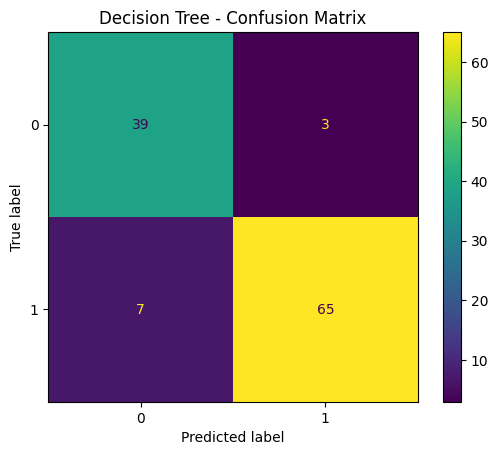


--- Random Forest ---
Accuracy: 0.956140350877193
AUC: 0.9930555555555556

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
 [[39  3]
 [ 2 70]]


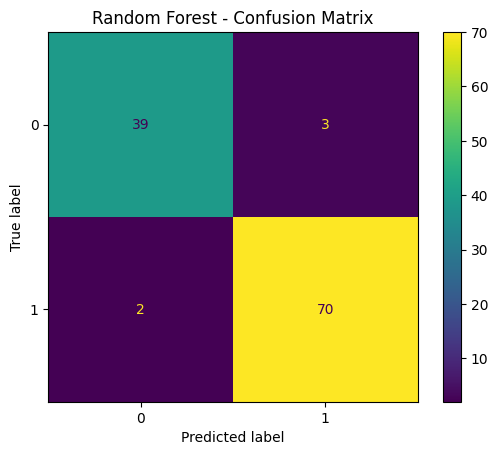

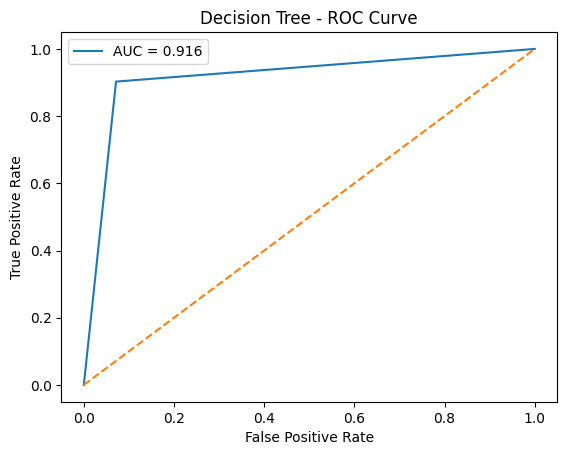

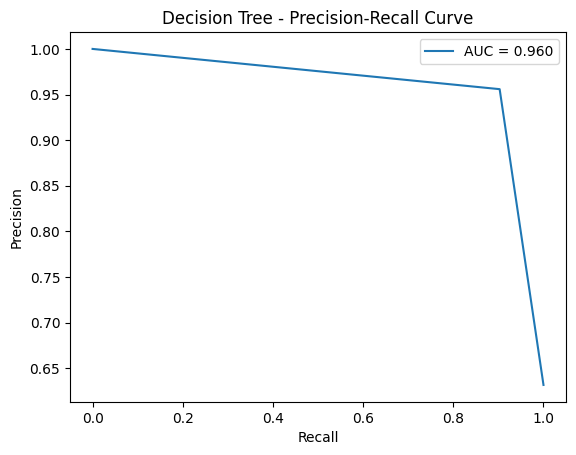

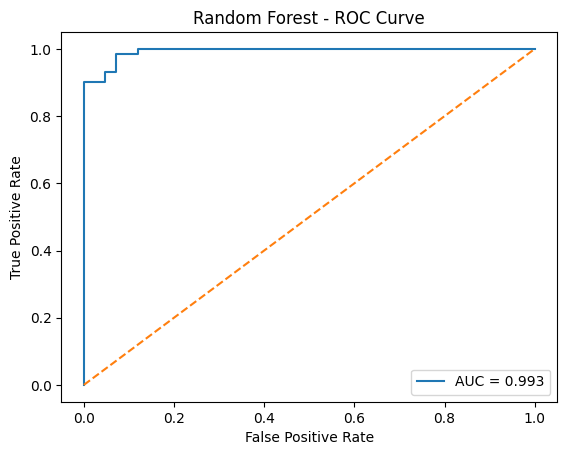

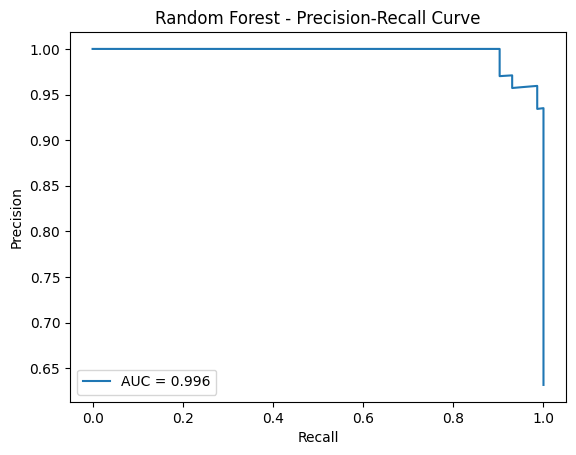

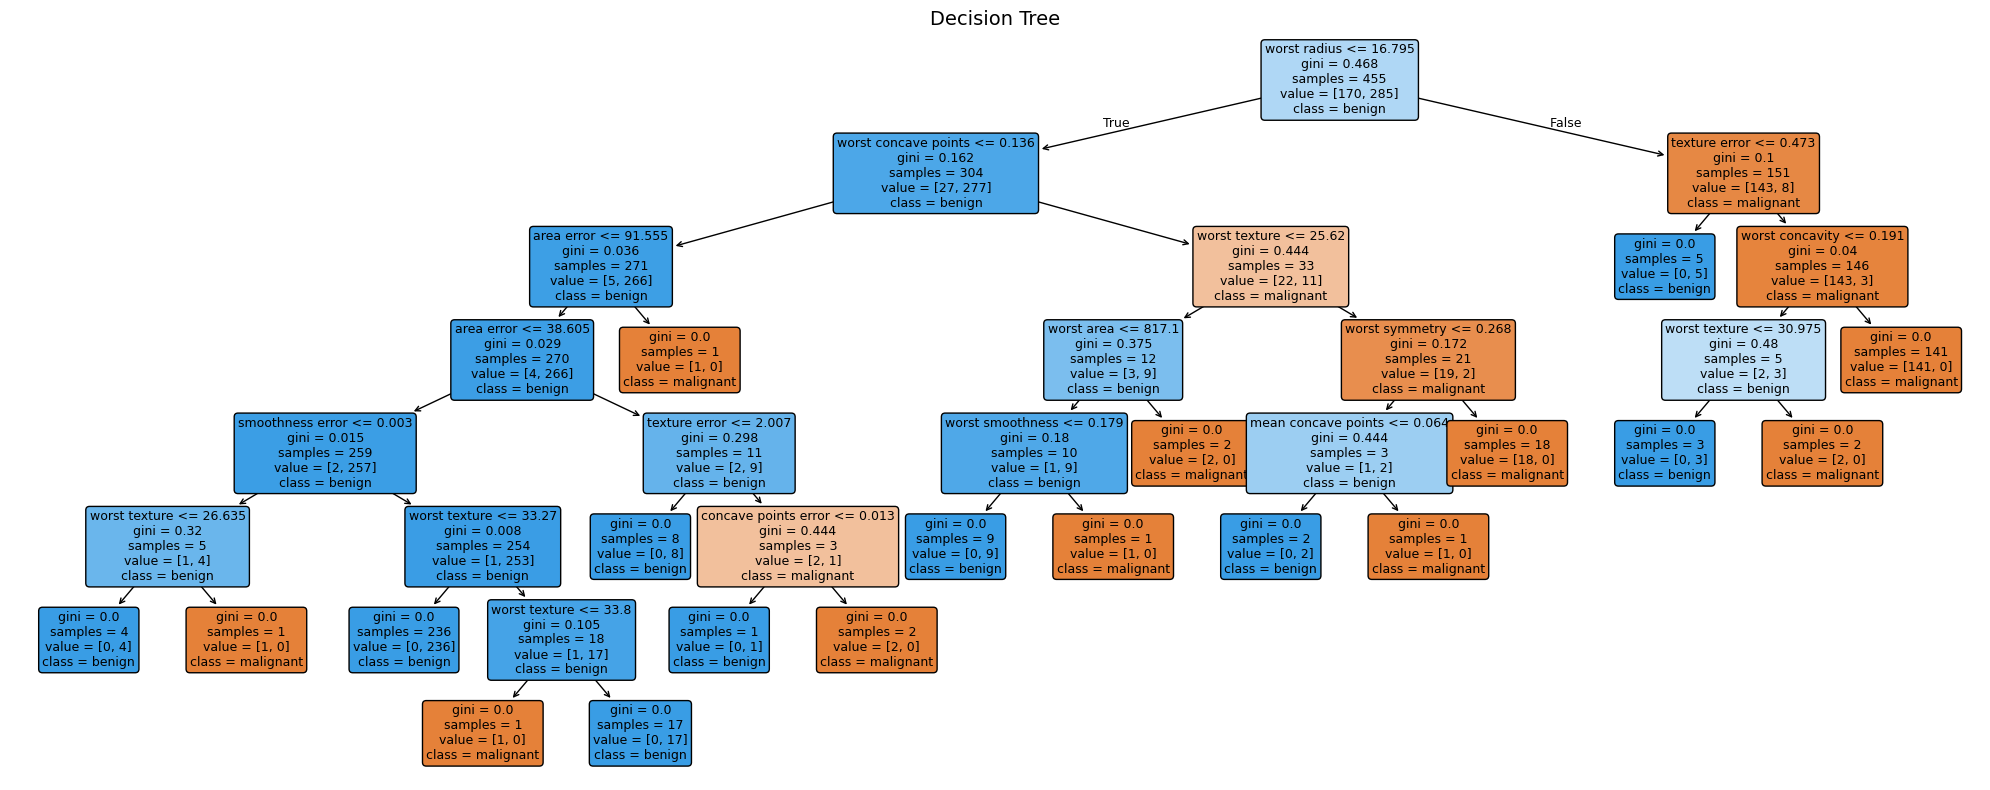

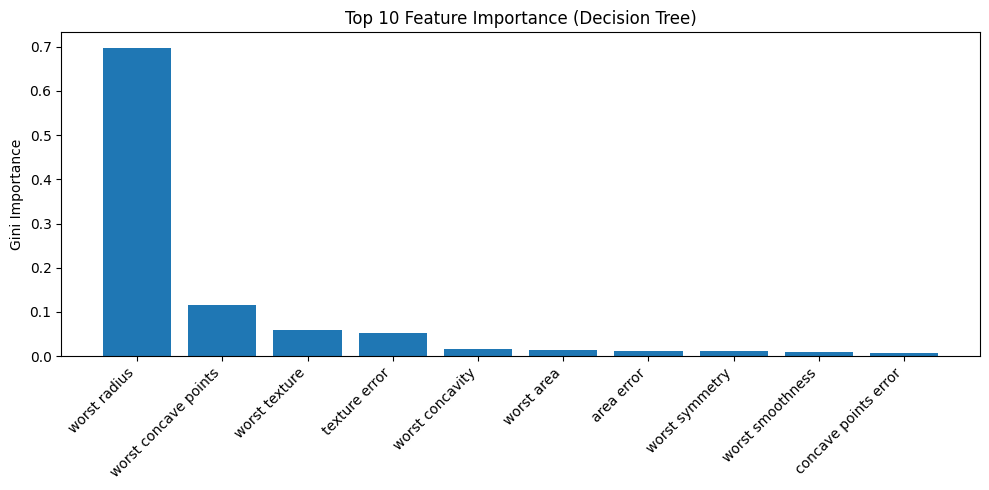


==================== ENSEMBLE DEMO ====================
Accuratezza del modello Decision Tree: 0.9173
Accuratezza media Bagging (Random Forest): 0.9561
Accuratezza media Boosting (Gradient Boosting): 0.9631


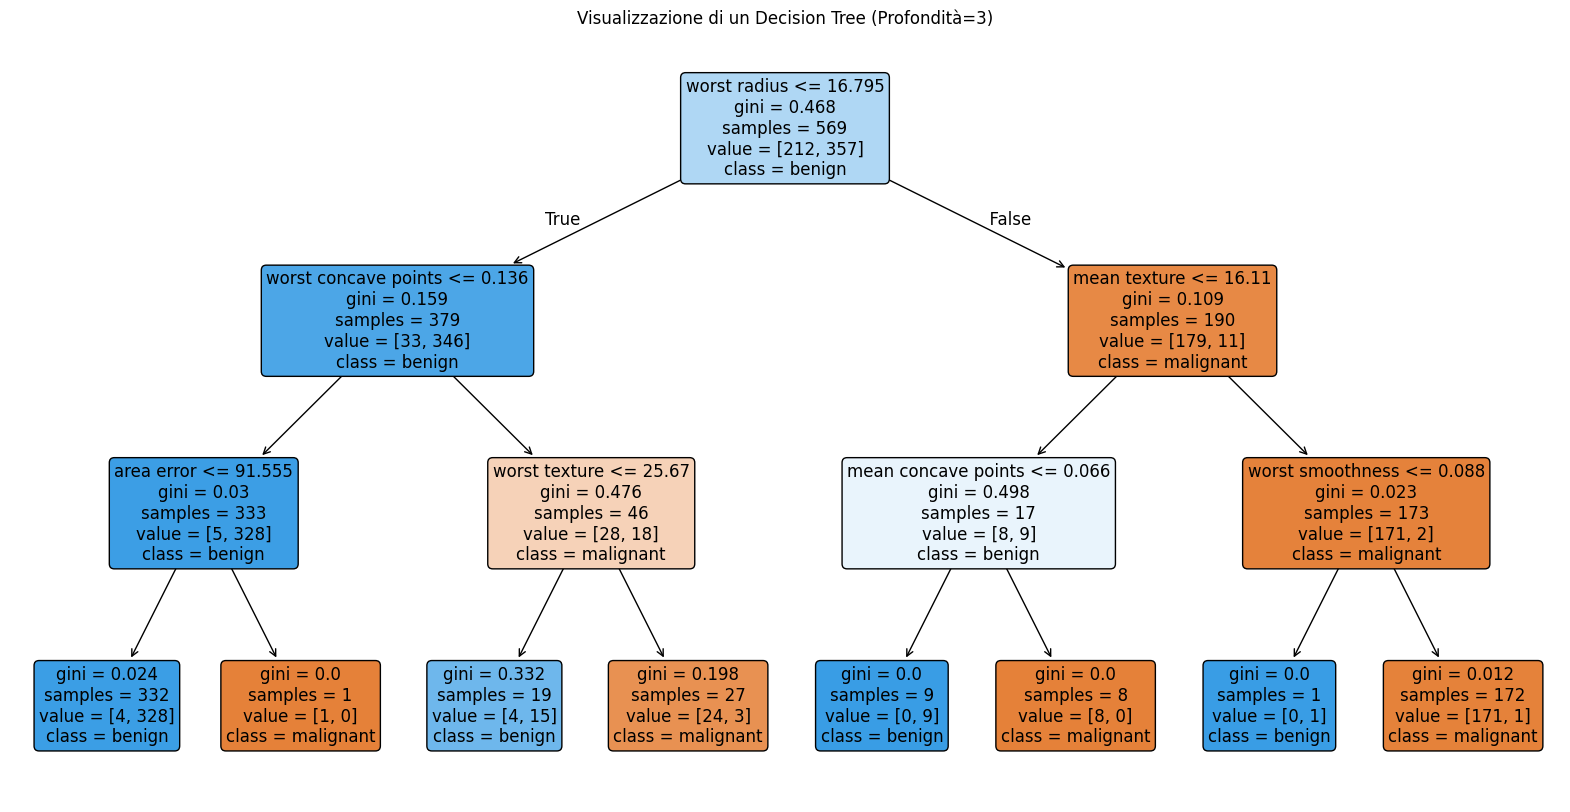


==================== UCI BANK MARKETING ====================
{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type

In [1]:
# ============================================================
# MAIN NOTEBOOK ORDINATO (DA SCREENSHOT)
# ============================================================
# Sezioni:
# A) Breast Cancer completo (Gruppi 1→4 + 5A + 5B)
# B) Ensemble demo separata (5C)
# C) UCI Bank Marketing separato (5D)
#
# Nota didattica:
# - La sezione A è una pipeline “corretta”: split -> CV sul TRAIN -> fit finale -> test -> grafici.
# - La sezione B è una demo didattica: CV su tutto X,y (come nelle slide).
# - La sezione C è solo download + info dataset (serve poi preprocessing se vuoi addestrare).
# ============================================================


# ============================================================
# A) BREAST CANCER COMPLETO
# ============================================================

# ----------------------------
# A1) Import + Caricamento dataset + Info + Split
# ----------------------------

from sklearn.datasets import load_breast_cancer              # dataset di esempio
from sklearn.model_selection import train_test_split         # split train/test
import pandas as pd                                          # per value_counts
import numpy as np                                           # per ordinare feature importance
import matplotlib.pyplot as plt                              # grafici

# Carico il dataset
data = load_breast_cancer()

# X = matrice delle feature (569 righe, 30 colonne)
X = data.data

# y = etichette: 0 = malignant, 1 = benign
y = data.target

# Info utili sul dataset
print(f"Dimensione dataset: {X.shape}")
print(f"Classi: {data.target_names}")
print(f"Distribuzione classi: {pd.Series(y).value_counts().to_dict()}")

# Split train/test (80% train, 20% test)
# stratify=y mantiene le proporzioni delle classi uguali in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} campioni")
print(f"Test: {X_test.shape[0]} campioni")


# ----------------------------
# A2) Modelli + Cross Validation (solo TRAIN) + Fit finale + Predizioni base
# ----------------------------

from sklearn.tree import DecisionTreeClassifier              # Decision Tree
from sklearn.ensemble import RandomForestClassifier          # Random Forest (bagging)
from sklearn.model_selection import cross_val_score          # cross validation

# Modello 1: Decision Tree
tree_model = DecisionTreeClassifier(
    random_state=42
)

# Modello 2: Random Forest
# n_estimators=200 nelle ultime immagini (in alcune era 100)
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1   # usa tutti i core CPU
)

# Cross Validation solo su TRAIN (così il TEST resta “pulito”)
# scoring='roc_auc' perché nelle slide usano AUC
tree_cv_scores = cross_val_score(
    tree_model, X_train, y_train,
    cv=5,
    scoring="roc_auc"
)

rf_cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5,
    scoring="roc_auc"
)

print("\n--- CROSS VALIDATION (solo TRAIN) ---")
print("Decision Tree CV AUC:", tree_cv_scores.mean())
print("Random Forest CV AUC:", rf_cv_scores.mean())

# Fit finale su tutto il TRAIN (dopo CV)
tree_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Predizioni su TEST
tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# Probabilità classe positiva (colonna 1)
tree_proba = tree_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Piccolo controllo (come negli screen)
print("\n--- CONTROLLO OUTPUT ---")
print("Prime 5 predizioni (Tree):", tree_pred[:5])
print("Prime 5 probabilità (Tree):", tree_proba[:5].round(3))
print("Shape X_test:", X_test.shape)
print("Shape tree_pred:", tree_pred.shape)


# ----------------------------
# A3) Valutazione completa: Accuracy + AUC + Report + Confusion Matrix
# ----------------------------

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Metto i modelli in un dizionario per ciclare
models = {
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

print("\n==================== TEST PERFORMANCE ====================")

for name, model in models.items():

    print(f"\n--- {name} ---")

    # Predizione classi e probabilità
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # AUC
    auc_score = roc_auc_score(y_test, y_proba)
    print("AUC:", auc_score)

    # Report precision/recall/f1
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix (stampa + plot)
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


# ----------------------------
# A4) Curve: ROC + Precision-Recall
# ----------------------------

from sklearn.metrics import roc_curve, precision_recall_curve, auc

for name, model in models.items():

    # Probabilità classe positiva
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---- ROC Curve ----
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")  # modello casuale
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()

    # ---- Precision-Recall Curve ----
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} - Precision-Recall Curve")
    plt.legend()
    plt.show()


# ----------------------------
# A5) (5A) Visualizzazione dell’albero Decision Tree
# ----------------------------

from sklearn.tree import plot_tree

# Nota: il plot dell'albero è leggibile solo se l'albero non è troppo profondo.
# Se vuoi renderlo più leggibile, imposta max_depth nel DecisionTreeClassifier.
plt.figure(figsize=(20, 8))

plot_tree(
    tree_model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree", fontsize=14)
plt.tight_layout()
plt.show()


# ----------------------------
# A6) (5B) Feature importance (Top 10) del Decision Tree
# ----------------------------

# Importanza calcolata dall'albero (in base a riduzione impurità Gini)
importances = tree_model.feature_importances_

# Ordino indici dalla più importante alla meno importante
indices = np.argsort(importances)[::-1][:10]  # top 10

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices])

plt.xticks(
    range(10),
    data.feature_names[indices],
    rotation=45,
    ha="right"
)

plt.title("Top 10 Feature Importance (Decision Tree)")
plt.ylabel("Gini Importance")
plt.tight_layout()
plt.show()


# ============================================================
# B) ENSEMBLE DEMO SEPARATA (5C) — Bagging vs Boosting
# ============================================================

# Nota didattica:
# Questa sezione è una demo “come nelle slide”:
# cross_val_score viene applicato su tutto X,y.
# In un progetto reale spesso si fa split e CV solo su train.

from sklearn.ensemble import GradientBoostingClassifier

# Dataset (riprovo a caricarlo per avere sezione indipendente)
data_demo = load_breast_cancer()
X_demo, y_demo = data_demo.data, data_demo.target

# Modelli
bagging_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

tree_model_base = DecisionTreeClassifier(
    random_state=42
)

# Cross Validation su tutto X,y
bagging_scores = cross_val_score(bagging_model, X_demo, y_demo, cv=5)
boosting_scores = cross_val_score(boosting_model, X_demo, y_demo, cv=5)
tree_scores = cross_val_score(tree_model_base, X_demo, y_demo, cv=5)

print("\n==================== ENSEMBLE DEMO ====================")
print(f"Accuratezza del modello Decision Tree: {tree_scores.mean():.4f}")
print(f"Accuratezza media Bagging (Random Forest): {bagging_scores.mean():.4f}")
print(f"Accuratezza media Boosting (Gradient Boosting): {boosting_scores.mean():.4f}")

# Albero piccolo per visualizzazione (solo demo)
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_demo, y_demo)

plt.figure(figsize=(20, 10))
plot_tree(
    small_tree,
    feature_names=data_demo.feature_names,
    class_names=data_demo.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Visualizzazione di un Decision Tree (Profondità=3)")
plt.show()


# ============================================================
# C) UCI BANK MARKETING (5D) — Download + Info
# ============================================================

# Nota:
# Questa sezione mostra solo come scaricare e vedere metadata/variabili.
# Per allenare un modello su questo dataset servono di solito:
# - gestione colonne categoriche (OneHotEncoder)
# - gestione di target (convertire in 0/1)
# - pipeline (ColumnTransformer)
# Queste parti NON erano nelle screenshot.

from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X_bank = bank_marketing.data.features
y_bank = bank_marketing.data.targets

# metadata
print("\n==================== UCI BANK MARKETING ====================")
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

# (Opzionale) spesso y_bank è un DataFrame con 1 colonna: lo trasformo in Series
# ⚠️ Questa riga non era chiaramente visibile in tutte le immagini,
# ma serve quasi sempre per lavorare comodo in sklearn.
y_bank = y_bank.iloc[:, 0]
